In [7]:
import numpy as np
import pandas as pd
import deeplenstronomy.deeplenstronomy as dl

from pathlib import Path
import os

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(repo_root)

dataset = dl.make_dataset(
    "data/binary_lens_config.yaml",
    save_to_disk=True,
    store_in_memory=True,
    image_file_format="npy",
    verbose=True,
)

lens_images = dataset.CONFIGURATION_1_images
no_lens_images = dataset.CONFIGURATION_2_images

X = np.concatenate([lens_images, no_lens_images], axis=0)
y = np.concatenate([
    np.ones(len(lens_images), dtype=np.int64),
    np.zeros(len(no_lens_images), dtype=np.int64),
])

lens_metadata = dataset.CONFIGURATION_1_metadata.copy()
lens_metadata["label"] = 1
lens_metadata["class_name"] = "LENS_PRESENT"

no_lens_metadata = dataset.CONFIGURATION_2_metadata.copy()
no_lens_metadata["label"] = 0
no_lens_metadata["class_name"] = "NO_LENS"

metadata = pd.concat([lens_metadata, no_lens_metadata], ignore_index=True)

print(X.shape)
print(y.shape)
print(metadata["label"].value_counts().sort_index())

Entering main organization loop
Organizing CONFIGURATION_1
Organizing CONFIGURATION_2
Generating images for CONFIGURATION_1
	Progress: 100.0 %  ---  Elapsed Time: 0 H 0 M 29 S         
Generating images for CONFIGURATION_2
	Progress: 100.0 %  ---  Elapsed Time: 0 H 0 M 23 S         
(998, 5, 100, 100)
(998,)
label
0    499
1    499
Name: count, dtype: int64


In [812]:
rng = np.random.default_rng(42)
indices = rng.permutation(len(y))

X = X[indices]
y = y[indices]
metadata = metadata.iloc[indices].reset_index(drop=True)

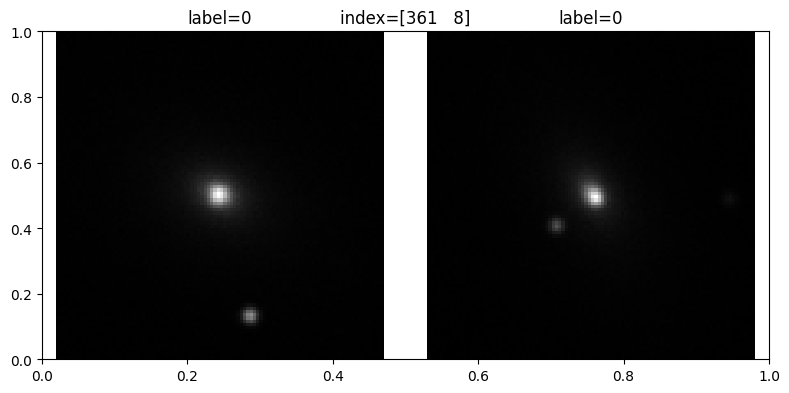

In [ ]:
import matplotlib.pyplot as plt

def show_sample(image, label):
    # Images have shape (bands, height, width). Show the first band.
    plt.imshow(image[0], origin="lower", cmap="gray")
    plt.title(f"label={label}",)
    plt.axis("off")

sample_indices = np.random.choice(len(y), size=2, replace=False)

plt.figure(figsize=(8, 4))
plt.title(f"index={sample_indices}")
for plot_idx, sample_idx in enumerate(sample_indices, start=1):
    plt.subplot(1, 2, plot_idx)
    show_sample(X[sample_idx], y[sample_idx])
plt.tight_layout()
plt.show()